# Notebook C - Safety Ceiling

Exp 7 (`safety_objective`, centralized dispatch, no distance constraint, no
preferences) is the theoretical safety ceiling; Exp 1 (`nearest`) is the floor.
For every other algorithm we ask: what fraction of the floor-to-ceiling safety
gain does it capture organically?

    ceiling_fraction = (safety - safety_exp1) / (safety_exp7 - safety_exp1)

Summary data only. Run separately for each geometry.

In [1]:
from pathlib import Path

GEOMETRY = 'balanced'          # 'balanced' or 'imbalanced'
FLOOR_EXP = 'exp1'             # nearest baseline
CEILING_EXP = 'exp7'           # centralized safety objective

# Minimum floor-to-ceiling safety gap (in safety-score units) for the ceiling
# fraction to be considered meaningful. Operating points with a smaller (or
# negative) gap are flagged and excluded from the fraction plots.
GAP_MIN = 0.5

CACHE_DIR = Path('.') / 'cache'
FORCE_RECOMPUTE = False

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from exp_utils import (load_experiment_set, compute_ceiling_fraction,
                       match_run_pairs, fmt_display, legend_outside)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
# Crop whitespace on save so legends placed outside the axes are captured.
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.03

## 1. Load all experiments for the chosen geometry

In [3]:
df = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR, force=FORCE_RECOMPUTE)
if df.empty:
    raise RuntimeError(f'No data for geometry={GEOMETRY!r}. Run cache_all.py first.')

avail = set(df['experiment'].unique())
for need in (FLOOR_EXP, CEILING_EXP):
    if need not in avail:
        raise RuntimeError(f'{need} missing for {GEOMETRY}; ceiling analysis needs it.')

EXPERIMENTS = sorted(avail)
EXP_ALGO = df.drop_duplicates('experiment').set_index('experiment')['algorithm'].to_dict()
EXP_LABEL = {e: f'{e}: {EXP_ALGO[e]}' for e in EXPERIMENTS}
_cmap = plt.get_cmap('tab10')
EXP_COLOR = {e: _cmap(i % 10) for i, e in enumerate(EXPERIMENTS)}

# Algorithms whose ceiling fraction we report (everything except floor/ceiling).
MID_EXPS = [e for e in EXPERIMENTS if e not in (FLOOR_EXP, CEILING_EXP)]

R_vals = sorted(df['R'].dropna().unique())
KEYS = ['d', 'R', 'behaviour', 'initial_conditions']

print(f'Geometry: {GEOMETRY}   floor={FLOOR_EXP}  ceiling={CEILING_EXP}')
print(f'Reporting ceiling fraction for: {[EXP_LABEL[e] for e in MID_EXPS]}')

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary
Geometry: balanced   floor=exp1  ceiling=exp7
Reporting ceiling fraction for: ['exp2: nearest_region_pref', 'exp3: nearest_distance_pref', 'exp4: nearest_passenger_pref', 'exp5: nearest_two_sided_region_pass_pref', 'exp6: safety_objective_two_sided']


## 2. Raw safety scores

Where each algorithm sits relative to the floor (Exp 1) and ceiling (Exp 7),
averaged over d / behaviour / ic.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for e in EXPERIMENTS:
    sub = df[df['experiment'] == e]
    g = sub.groupby('R')['final_safety_mean'].mean().reindex(R_vals)
    style = dict(linewidth=1.6, markersize=5, linestyle='-')
    if e == FLOOR_EXP:
        style.update(linewidth=2.6, linestyle='--')
    elif e == CEILING_EXP:
        style.update(linewidth=2.6, linestyle=':')
    ax.plot(R_vals, g.values, marker='o', color=EXP_COLOR[e], label=EXP_LABEL[e], **style)
ax.set_xlabel('Demand ratio R')
ax.set_ylabel('Mean driver safety')
ax.set_title(f'Raw safety scores by algorithm - {GEOMETRY}')
ax.set_xticks(R_vals)
fig.tight_layout()
legend_outside(fig, ax=ax)
plt.show()

## 3. Safety ceiling fraction

For each algorithm at each operating point, fraction of the Exp1 -> Exp7 safety
gap captured. Bars grouped by R, averaged over d / behaviour / ic. Operating
points with a floor-to-ceiling gap below `GAP_MIN` are excluded (see caveat).

385 of 420 runs have gap <= 0.5 (excluded from fraction).
valid runs per R: {0.2: 7, 0.5: 0, 1.0: 28}


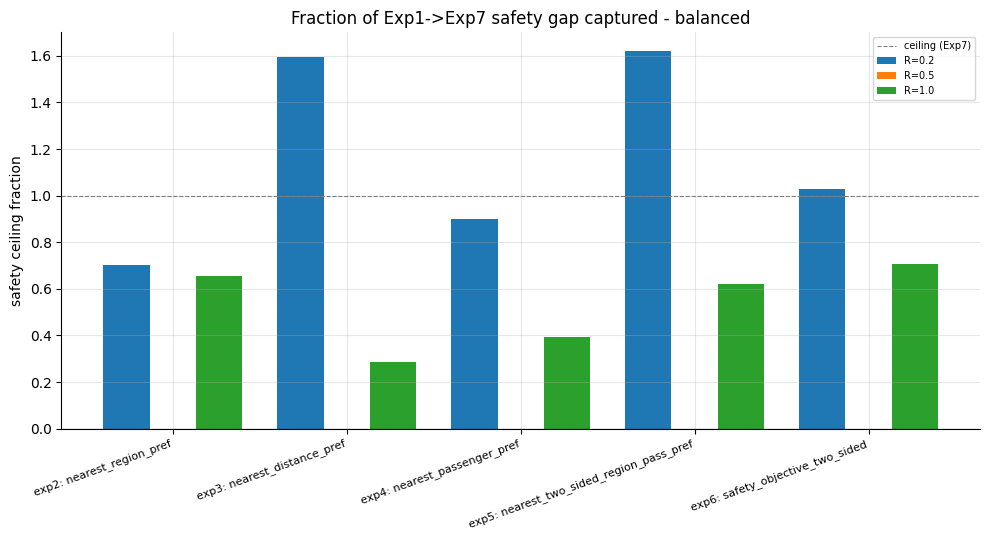

In [5]:
cf = compute_ceiling_fraction(df, FLOOR_EXP, CEILING_EXP, 'final_safety_mean', keys=KEYS)
gap = cf['ceiling'] - cf['floor']
cf['ceiling_fraction_valid'] = cf['ceiling_fraction'].where(gap > GAP_MIN)

n_flag = int((gap <= GAP_MIN).sum())
print(f'{n_flag} of {len(cf)} runs have gap <= {GAP_MIN} (excluded from fraction).')
print('valid runs per R:',
      cf[gap > GAP_MIN].groupby('R').size().reindex(R_vals).fillna(0).astype(int).to_dict())

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(MID_EXPS))
w = 0.8 / max(len(R_vals), 1)
for i, r in enumerate(R_vals):
    vals = [cf[(cf['experiment'] == e) & (cf['R'] == r)]['ceiling_fraction_valid'].mean()
            for e in MID_EXPS]
    ax.bar(x + i * w, vals, w, label=f'R={r}')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1, color='gray', linewidth=0.8, linestyle='--', label='ceiling (Exp7)')
ax.set_xticks(x + w * (len(R_vals) - 1) / 2)
ax.set_xticklabels([EXP_LABEL[e] for e in MID_EXPS], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('safety ceiling fraction')
ax.set_title(f'Fraction of Exp1->Exp7 safety gap captured - {GEOMETRY}')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 4. Service cost vs safety gain

x = delta service rate vs Exp 1; y = safety ceiling fraction. Each point is one
algorithm x d x R. Upper-right = captures safety gains without hurting service.

In [ ]:
base_sr = (df[df['experiment'] == FLOOR_EXP][KEYS + ['service_rate']]
           .rename(columns={'service_rate': 'service_rate_floor'}))
sc = cf.merge(base_sr, on=KEYS, how='left')
sc['delta_service'] = sc['service_rate'] - sc['service_rate_floor']
sc = sc[(sc['experiment'].isin(MID_EXPS)) & sc['ceiling_fraction_valid'].notna()]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for e in MID_EXPS:
    s = sc[sc['experiment'] == e]
    ax.scatter(s['delta_service'], s['ceiling_fraction_valid'],
               s=25 + s['R'] * 130, color=EXP_COLOR[e], label=EXP_LABEL[e],
               alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('delta service rate vs Exp 1')
ax.set_ylabel('safety ceiling fraction')
ax.set_title(f'Service cost vs safety gain - {GEOMETRY}  (marker size ~ R)')
fig.tight_layout()
legend_outside(fig, ax=ax)
plt.show()

## 5. Exp 6 vs Exp 7: cost of adding preferences to the safety objective

Exp 6 = safety objective + two-sided preferences; Exp 7 = pure safety objective.
How far do preferences drag safety below the pure ceiling, and what is the
service-rate difference? Negative delta safety = Exp 6 is below the ceiling.

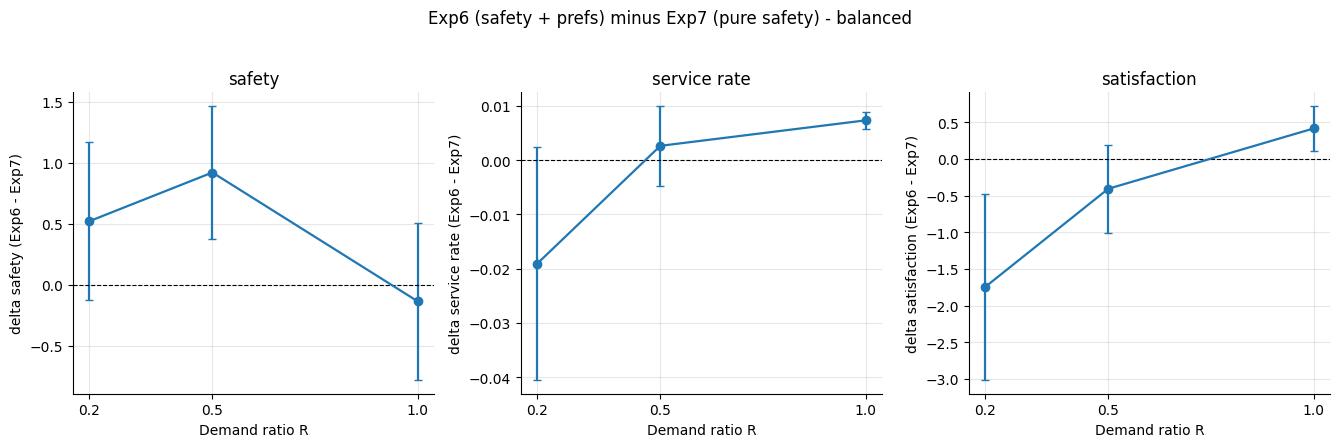

In [7]:
if 'exp6' in avail and 'exp7' in avail:
    m = match_run_pairs(df[df['experiment'] == 'exp7'],
                        df[df['experiment'] == 'exp6'], keys=KEYS)
    metrics = [('final_safety_mean', 'safety'),
               ('service_rate', 'service rate'),
               ('final_satisfaction_mean', 'satisfaction')]
    metrics = [(c, l) for c, l in metrics if f'{c}_exp1' in m.columns]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 4.3))
    axes = np.atleast_1d(axes)
    for ax, (col, label) in zip(axes, metrics):
        dlt = (m[f'{col}_exp2'] - m[f'{col}_exp1'])   # exp6 - exp7
        tmp = pd.DataFrame({'R': m['R'], 'delta': dlt})
        g = tmp.groupby('R')['delta'].agg(['mean', 'std']).reindex(R_vals)
        ax.errorbar(R_vals, g['mean'].values, yerr=g['std'].values, fmt='o-',
                    capsize=3, linewidth=1.6)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('Demand ratio R')
        ax.set_ylabel(f'delta {label} (Exp6 - Exp7)')
        ax.set_title(label)
        ax.set_xticks(R_vals)
    fig.suptitle(f'Exp6 (safety + prefs) minus Exp7 (pure safety) - {GEOMETRY}', y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print('exp6 and/or exp7 not available for this geometry.')

## 6. Summary: mean ceiling fraction by algorithm

Across all valid (gap > GAP_MIN) operating points.

In [8]:
rows = []
for e in MID_EXPS:
    s = cf[(cf['experiment'] == e)]
    valid = s['ceiling_fraction_valid'].dropna()
    rows.append({
        'algorithm': EXP_LABEL[e],
        'mean_ceiling_fraction': valid.mean() if len(valid) else np.nan,
        'median_ceiling_fraction': valid.median() if len(valid) else np.nan,
        'n_valid': int(len(valid)),
    })
tbl = pd.DataFrame(rows).sort_values('mean_ceiling_fraction', ascending=False)
display(fmt_display(tbl, fmt={'mean_ceiling_fraction': '{:.3f}',
                              'median_ceiling_fraction': '{:.3f}'}))

,algorithm,mean_ceiling_fraction,median_ceiling_fraction,n_valid
3,exp5: nearest_two_sided_region_pass_pref,0.820,0.818,5
4,exp6: safety_objective_two_sided,0.771,0.735,5
0,exp2: nearest_region_pref,0.666,0.701,5
1,exp3: nearest_distance_pref,0.549,0.496,5
2,exp4: nearest_passenger_pref,0.494,0.586,5


## Significance

Two complementary tests (see `guides/STATISTICAL_ANALYSIS_PLAN.md`):

- **Sweep** - paired Wilcoxon signed-rank across the x1 sweep, points paired by
  d / R / behaviour / ic. The headline test. `sweep_cliff` is Cliff's delta,
  `sweep_signs` the sign-agreement count, `sweep_p_adj` the Holm-corrected p.
- **Focus** - replicate test at the focus operating point
  (d=258, R=0.5, go_back, ic=home; K=11 runs per algorithm). `foc_diff` and its
  95% CI are the Welch mean difference; `foc_cohens_d` / `foc_cliff` are the
  effect sizes; `foc_welch_p` / `foc_mw_p` the Welch and Mann-Whitney p-values.

Positive deltas mean the first algorithm scores higher. P-values are Holm-corrected
within each metric across the comparisons. Inequality (Gini) is never t-tested: its
focus p-value is Mann-Whitney and the headline inequality claim uses a bootstrap CI
(below). Trajectories are compared in `safety_evolution.ipynb`, not by per-timestamp
tests (successive batches are autocorrelated).

In [9]:
from exp_utils import significance_summary, FOCUS_SETUP

df_reps = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR, include_reps=True,
                              force=FORCE_RECOMPUTE)

# Safety-aware algorithms vs the nearest floor, and the two safety variants vs each other.
_cand = [('exp6', 'exp1'), ('exp7', 'exp1'), ('exp6', 'exp7')]
COMPARISONS = [(a, b) for a, b in _cand if a in avail and b in avail]
SIG_METRICS = [m for m in ['final_safety_mean', 'service_rate', 'final_satisfaction_mean',
                           'income_gini'] if m in df.columns]

sig = significance_summary(df, df_reps, COMPARISONS, SIG_METRICS, setup=FOCUS_SETUP)
SIG_SHOW = ['comparison', 'metric', 'sweep_n', 'sweep_p_adj', 'sweep_cliff', 'sweep_mag',
            'sweep_signs', 'foc_diff', 'foc_ci_lo', 'foc_ci_hi', 'foc_welch_p',
            'foc_mw_p', 'foc_p_adj', 'foc_cohens_d']
SIG_FMT = {'sweep_p_adj': '{:.2g}', 'sweep_cliff': '{:+.2f}', 'foc_diff': '{:+.3f}',
           'foc_ci_lo': '{:+.3f}', 'foc_ci_hi': '{:+.3f}', 'foc_welch_p': '{:.2g}',
           'foc_mw_p': '{:.2g}', 'foc_p_adj': '{:.2g}', 'foc_cohens_d': '{:+.2f}'}
SIG_SHOW = [c for c in SIG_SHOW if c in sig.columns]
display(fmt_display(sig[SIG_SHOW], fmt=SIG_FMT))

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary


,comparison,metric,sweep_n,sweep_p_adj,sweep_cliff,sweep_mag,sweep_signs,foc_diff,foc_ci_lo,foc_ci_hi,foc_welch_p,foc_mw_p,foc_p_adj,foc_cohens_d
0,exp6 vs exp1,final_safety_mean,60,0.59,-0.01,negligible,34/60 a<b,-0.333,-0.629,-0.037,0.029,0.036,0.029,-1.01
1,exp6 vs exp1,service_rate,60,4.1e-10,-0.16,small,55/60 a<b,-0.000,-0.002,+0.002,0.84,0.84,0.84,-0.09
2,exp6 vs exp1,final_satisfaction_mean,60,4.9e-11,-0.32,small,60/60 a<b,-0.769,-0.943,-0.596,1.2e-08,8.2e-05,3.5e-08,-3.95
3,exp6 vs exp1,income_gini,60,3.5e-10,+0.35,medium,54/60 a>b,+0.008,+0.007,+0.010,-,8.2e-05,0.00024,-
4,exp7 vs exp1,final_safety_mean,60,0.00026,-0.15,small,45/60 a<b,-1.376,-1.620,-1.132,2e-10,8.2e-05,6.1e-10,-5.02
5,exp7 vs exp1,service_rate,60,8.2e-10,-0.25,small,55/60 a<b,-0.008,-0.009,-0.006,2.6e-08,8.2e-05,5.2e-08,-4.15
6,exp7 vs exp1,final_satisfaction_mean,60,7.3e-11,-0.28,small,56/60 a<b,-0.662,-0.844,-0.479,2.9e-07,8.2e-05,5.7e-07,-3.22
7,exp7 vs exp1,income_gini,60,7e-11,+0.45,medium,58/60 a>b,+0.012,+0.010,+0.013,-,8.2e-05,0.00024,-
8,exp6 vs exp7,final_safety_mean,60,0.00017,+0.16,small,44/60 a>b,+1.043,+0.754,+1.331,5.1e-07,0.00011,1e-06,+3.24
9,exp6 vs exp7,service_rate,60,0.65,+0.12,negligible,41/60 a>b,+0.007,+0.006,+0.009,1.3e-08,8.2e-05,4e-08,+4.24


In [10]:
# Safety inequality across drivers: bootstrap CI of the safety-Gini difference at
# the focus setup, taxi-level safety vectors pooled across replicates.
from exp_utils import pooled_focus_taxi_values, bootstrap_gini_diff_ci

rows = []
for a, b in COMPARISONS:
    va = pooled_focus_taxi_values(GEOMETRY, a, 'safety_score')
    vb = pooled_focus_taxi_values(GEOMETRY, b, 'safety_score')
    r = bootstrap_gini_diff_ci(va, vb, n_boot=1000, seed=0)
    rows.append({'comparison': f'{a} vs {b}', 'safety_gini_a': r['gini_a'],
                 'safety_gini_b': r['gini_b'], 'gini_diff': r['diff'],
                 'ci_lo': r['lo'], 'ci_hi': r['hi'], 'ci_excludes_0': r['significant']})
display(fmt_display(pd.DataFrame(rows),
    fmt={'safety_gini_a': '{:.4f}', 'safety_gini_b': '{:.4f}', 'gini_diff': '{:+.4f}',
         'ci_lo': '{:+.4f}', 'ci_hi': '{:+.4f}'}))

[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary


,comparison,safety_gini_a,safety_gini_b,gini_diff,ci_lo,ci_hi,ci_excludes_0
0,exp6 vs exp1,0.1132,0.1240,-0.0108,-0.0126,-0.0091,True
1,exp7 vs exp1,0.1207,0.1240,-0.0033,-0.0051,-0.0016,True
2,exp6 vs exp7,0.1132,0.1207,-0.0075,-0.0092,-0.0060,True
